# TP3 — Visión por Computadora I

Tema: detección de un logotipo mediante template matching multi-escala

Alumno: Ailen Muñoz, Romero Federico

---

### Objetivo

Encontrar el logotipo de la gaseosa en las imágenes de `images/` a partir del template `template/pattern.png`.

1. (4 puntos) Obtener una detección del logo en cada imagen, sin falsos positivos.
2. (4 puntos) Plantear y validar un algoritmo para múltiples detecciones en `coca_multi.png` con el mismo template.
3. (2 puntos) Generalizar el algoritmo del punto 2 a todas las imágenes.

Los resultados se muestran con bounding boxes y el nivel de confianza de cada detección.

### Cómo leer este notebook

- Las cajas con fondo y borde verde contienen las conclusiones del equipo.
- El resto de las celdas están agrupadas por punto y contienen el código relativo a ese punto.

## Setup


In [1]:
import os
import glob
import itertools
import time

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 80

IMAGES_DIR = "images"
TEMPLATE_PATH = os.path.join("template", "pattern.png")

assert os.path.isdir(IMAGES_DIR), f"No se encontró {IMAGES_DIR}. Revisar desde dónde se corre el notebook."
assert os.path.isfile(TEMPLATE_PATH), f"No se encontró {TEMPLATE_PATH}."

template_bgr = cv.imread(TEMPLATE_PATH, cv.IMREAD_COLOR)
imagenes = {os.path.basename(p): cv.imread(p, cv.IMREAD_COLOR)
            for p in sorted(glob.glob(os.path.join(IMAGES_DIR, "*")))}

print(f"Template: {template_bgr.shape[1]}x{template_bgr.shape[0]} px")
for nombre, img in imagenes.items():
    print(f"{nombre:22s} {img.shape[1]}x{img.shape[0]} px")

Template: 400x175 px
COCA-COLA-LOGO.jpg     1389x1389 px
coca_logo_1.png        207x500 px
coca_logo_2.png        233x363 px
coca_multi.png         799x598 px
coca_retro_1.png       715x493 px
coca_retro_2.png       715x429 px
logo_1.png             687x450 px


### El template y las imágenes

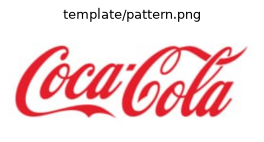

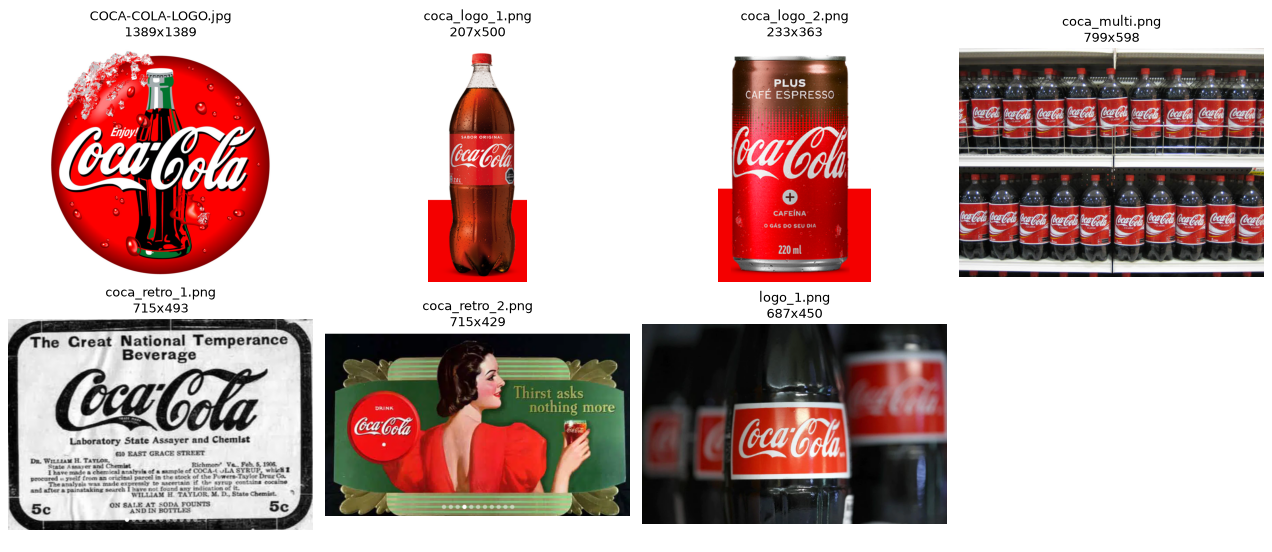

In [2]:
def bgr2rgb(img):
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)


plt.figure(figsize=(4, 2))
plt.imshow(bgr2rgb(template_bgr))
plt.title("template/pattern.png")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (nombre, img) in zip(axes.ravel(), imagenes.items()):
    ax.imshow(bgr2rgb(img))
    ax.set_title(f"{nombre}\n{img.shape[1]}x{img.shape[0]}")
    ax.axis("off")
axes.ravel()[-1].axis("off")
fig.tight_layout()
plt.show()

Tres cosas condicionan el diseño del detector:

- El logo aparece desde unos 60 px de ancho (cada etiqueta de `coca_multi.png`) hasta unos 1100 px (`COCA-COLA-LOGO.jpg`). El template mide 400 px y el template matching no es invariante a escala.
- El template es texto rojo sobre blanco, pero en las imágenes el logo es blanco sobre rojo o negro sobre blanco. El contraste está invertido.
- El logo está sobre superficies curvas, con tipografías levemente distintas, con desenfoque de fondo y rodeado de distractores (texto, brillos, zonas rojas lisas).

## Parte 1 — Una detección por imagen, sin falsos positivos

### 1.1 Punto de partida: `cv.matchTemplate` directo

Correlación normalizada (`TM_CCOEFF_NORMED`) del template a su escala original sobre la imagen en escala de grises, quedándonos con el máximo.

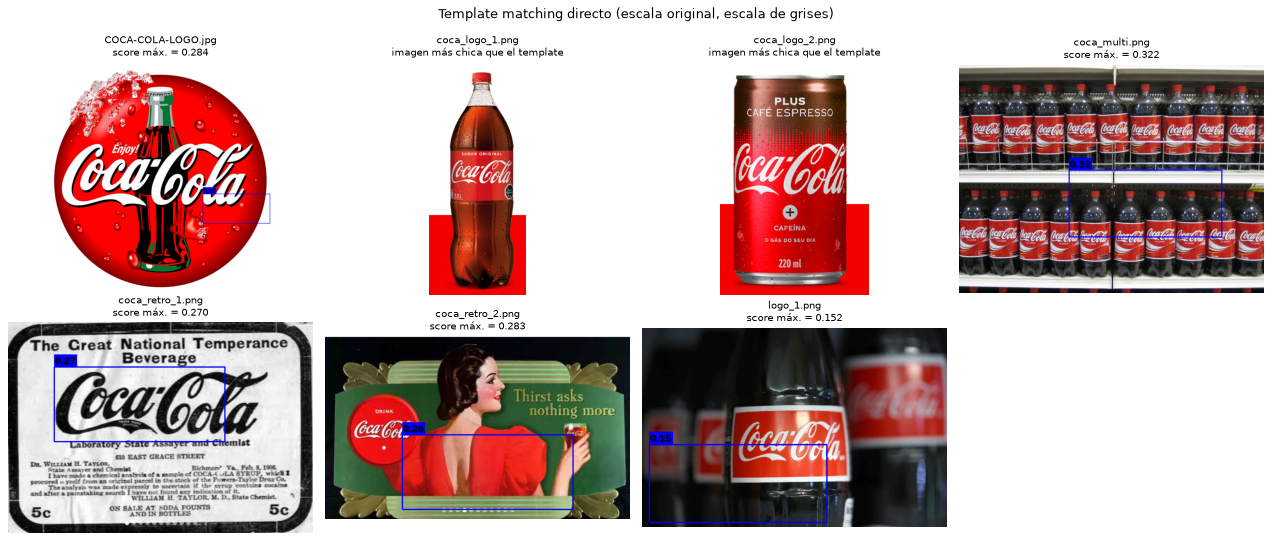

In [3]:
def dibujar_detecciones(img_bgr, detecciones, color=(0, 255, 0), grosor=2):
    '''Dibuja una lista de detecciones {"bbox": (x0, y0, x1, y1), "score": float} sobre una copia de la imagen.'''
    salida = img_bgr.copy()
    escala_texto = max(0.4, min(1.2, img_bgr.shape[1] / 900))
    for det in detecciones:
        x0, y0, x1, y1 = [int(round(v)) for v in det["bbox"]]
        cv.rectangle(salida, (x0, y0), (x1, y1), color, grosor)
        etiqueta = f"{det['score']:.2f}"
        (tw, th), _ = cv.getTextSize(etiqueta, cv.FONT_HERSHEY_SIMPLEX, escala_texto, 2)
        ty = y0 - 4 if y0 - th - 6 > 0 else y1 + th + 4
        cv.rectangle(salida, (x0, ty - th - 4), (x0 + tw + 4, ty + 2), color, -1)
        cv.putText(salida, etiqueta, (x0 + 2, ty - 2), cv.FONT_HERSHEY_SIMPLEX, escala_texto, (0, 0, 0), 2)
    return salida


def mostrar_grilla(resultados, titulo, ncols=4, figsize=(16, 7)):
    '''resultados: dict nombre -> (imagen_bgr_con_dibujos, subtitulo)'''
    n = len(resultados)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, (nombre, (img, sub)) in zip(axes, resultados.items()):
        ax.imshow(bgr2rgb(img))
        ax.set_title(f"{nombre}\n{sub}", fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()


template_gris = cv.cvtColor(template_bgr, cv.COLOR_BGR2GRAY)
th_t, tw_t = template_gris.shape

resultados_naive = {}
for nombre, img in imagenes.items():
    gris = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    if gris.shape[0] < th_t or gris.shape[1] < tw_t:
        resultados_naive[nombre] = (img, "imagen más chica que el template")
        continue
    res = cv.matchTemplate(gris, template_gris, cv.TM_CCOEFF_NORMED)
    _, max_val, _, max_loc = cv.minMaxLoc(res)
    det = {"bbox": (max_loc[0], max_loc[1], max_loc[0] + tw_t, max_loc[1] + th_t), "score": max_val}
    resultados_naive[nombre] = (dibujar_detecciones(img, [det], color=(255, 0, 0)), f"score máx. = {max_val:.3f}")

mostrar_grilla(resultados_naive, "Template matching directo (escala original, escala de grises)")

<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">

El enfoque directo falla en todas las imágenes. En `coca_logo_1.png` y `coca_logo_2.png` ni siquiera se puede aplicar porque la imagen es más angosta que el template. En el resto el máximo cae en cualquier lado menos en el logo, con scores menores a 0.35. Las causas son las dos que anticipamos: el template tiene un tamaño fijo que no coincide con el del logo en ninguna imagen, y su polaridad es la inversa a la de casi todos los logos, con lo cual la correlación tiende a ser negativa justo donde está el logo.

</div>

### 1.2 Diseño del detector

Atacamos los tres problemas por separado.

Escala. Fijamos el template a un ancho de trabajo de 100 px y reescalamos la imagen de forma que un logo hipotético de ancho $w$ pase a medir 100 px, barriendo $w$ en escala logarítmica hasta el ancho de la imagen. Reescalar el template en lugar de la imagen no funciona: a escalas chicas se convierte en una mancha de 20 px que correlaciona bien con cualquier cosa. Como el logo puede aparecer estirado o comprimido, probamos además tres relaciones de aspecto (0.8, 1.0 y 1.25).

No permitimos ampliar la imagen más de 1.5× (`factor_max`). Ampliar una región de 40 px a 100 px no agrega información: produce una versión borrosa donde las letras no se distinguen y la correlación normalizada deja de ser discriminativa. En los experimentos preliminares todos los falsos positivos aparecían en esas escalas. Esto fija un piso de unos 67 px de ancho para el logo, suficiente para las etiquetas más chicas del material.

Polaridad. `TM_CCOEFF_NORMED` resta la media y normaliza por la desviación estándar de cada ventana, así que es invariante a cambios afines de brillo. Si el contraste está invertido, el coeficiente cambia de signo pero conserva su magnitud. Tomando $|\rho|$ el detector responde igual a texto claro sobre fondo oscuro que al revés.

Tipografía, deformación y fondo. En lugar de correlacionar intensidades de gris, correlacionamos dos mapas de características calculados igual sobre el template y sobre la imagen reescalada:

1. Bordes suavizados: Canny seguido de un desenfoque gaussiano con $\sigma = 1$. El suavizado convierte el mapa binario en uno blando que tolera desalineaciones de uno o dos píxeles entre las letras del template y las de la imagen.
2. Gradientes orientados: las derivadas de Sobel $(G_x, G_y)$ suavizadas, como imagen de dos canales. A diferencia del módulo del gradiente conservan la orientación de los trazos, que es lo que distingue la caligrafía del logo de un renglón de texto. Bajo inversión de polaridad cambian de signo globalmente, así que el valor absoluto también las cubre.

El score final es el promedio de ambas correlaciones. Para cada escala nos quedamos con los máximos locales del mapa de respuesta y al final aplicamos supresión de no máximos por IoU entre escalas.

In [4]:
def extraer_caracteristicas(img_bgr, sigma=1.0):
    '''
    Calcula los mapas de características sobre los que se correlaciona.

    Se aplica exactamente igual al template (ya llevado al ancho de trabajo) y a la
    imagen reescalada, de manera que ambos "vean" el logo con la misma resolución.

    Returns
    -------
    dict con:
      "gris"      : intensidad suavizada (float32, 1 canal). Solo para comparar.
      "bordes"    : Canny + desenfoque gaussiano (float32, 1 canal).
      "gradiente" : (Gx, Gy) de Sobel suavizados (float32, 2 canales).
    '''
    gris = cv.GaussianBlur(cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY), (0, 0), 1.0)
    gris_f = gris.astype(np.float32)

    gx = cv.GaussianBlur(cv.Sobel(gris_f, cv.CV_32F, 1, 0, ksize=3), (0, 0), sigma)
    gy = cv.GaussianBlur(cv.Sobel(gris_f, cv.CV_32F, 0, 1, ksize=3), (0, 0), sigma)

    bordes = cv.Canny(gris, 50, 120).astype(np.float32)
    bordes = cv.GaussianBlur(bordes, (0, 0), sigma)

    return {
        "gris": cv.GaussianBlur(gris_f, (0, 0), sigma),
        "bordes": bordes,
        "gradiente": np.dstack([gx, gy]),
    }


def iou(a, b):
    '''Intersección sobre unión de dos cajas (x0, y0, x1, y1).'''
    ix0, iy0 = max(a[0], b[0]), max(a[1], b[1])
    ix1, iy1 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def supresion_no_maximos(detecciones, iou_max=0.3):
    '''Recorre las detecciones de mayor a menor score y descarta las que solapan (IoU > iou_max) con una ya aceptada.'''
    detecciones = sorted(detecciones, key=lambda d: -d["score"])
    aceptadas = []
    for det in detecciones:
        if all(iou(det["bbox"], a["bbox"]) <= iou_max for a in aceptadas):
            aceptadas.append(det)
    return aceptadas


def buscar_logo(img_bgr, template_bgr, pesos=None, ancho_trabajo=100, factor_max=1.5,
                n_escalas=30, aspectos=(0.8, 1.0, 1.25), score_min=0.10, iou_nms=0.3,
                radio_pico=7):
    '''
    Búsqueda multi-escala del template en la imagen.

    Devuelve una lista de detecciones {"score", "bbox", "ancho", "aspecto"} en coordenadas de la
    imagen original, ordenadas por score descendente y ya filtradas por NMS. NO aplica ningún
    umbral de decisión (eso lo hace el que llama): solo descarta candidatos con score < score_min
    para no acumular basura.

    Parameters
    ----------
    pesos : dict característica -> peso. Por defecto {"bordes": 0.5, "gradiente": 0.5}.
    ancho_trabajo : ancho (px) al que se lleva el template. La imagen se reescala para que un
        logo de ancho `w` pase a medir `ancho_trabajo`.
    factor_max : máximo factor de ampliación permitido para la imagen (piso de resolución).
    n_escalas : cantidad de anchos hipotéticos de logo a probar (escala logarítmica).
    aspectos : factores de alto/ancho relativos al template que se prueban.
    radio_pico : radio (px, en la imagen reescalada) para detectar máximos locales por escala.
    '''
    if pesos is None:
        pesos = {"bordes": 0.5, "gradiente": 0.5}

    tw = ancho_trabajo
    th = int(round(template_bgr.shape[0] * tw / template_bgr.shape[1]))
    feats_tpl = extraer_caracteristicas(cv.resize(template_bgr, (tw, th), interpolation=cv.INTER_AREA))

    H, W = img_bgr.shape[:2]
    anchos = np.geomspace(tw / factor_max, W * 1.05, n_escalas)
    kernel_pico = np.ones((2 * radio_pico + 1, 2 * radio_pico + 1), np.uint8)

    candidatos = []
    for ancho_logo, aspecto in itertools.product(anchos, aspectos):
        f = tw / ancho_logo                          # factor de escala de la imagen
        iw, ih = int(round(W * f)), int(round(H * f / aspecto))
        if iw < tw or ih < th:
            continue
        interp = cv.INTER_AREA if f < 1 else cv.INTER_LINEAR
        feats_img = extraer_caracteristicas(cv.resize(img_bgr, (iw, ih), interpolation=interp))

        respuesta = np.zeros((ih - th + 1, iw - tw + 1), np.float32)
        for k, w in pesos.items():
            respuesta += w * np.abs(cv.matchTemplate(feats_img[k], feats_tpl[k], cv.TM_CCOEFF_NORMED))

        # máximos locales de esta escala
        es_pico = respuesta == cv.dilate(respuesta, kernel_pico)
        ys, xs = np.where(es_pico & (respuesta >= score_min))
        for y, x in zip(ys, xs):
            candidatos.append({
                "score": float(respuesta[y, x]),
                "bbox": (x / f, y * aspecto / f, (x + tw) / f, (y + th) * aspecto / f),
                "ancho": float(ancho_logo),
                "aspecto": aspecto,
            })

    return supresion_no_maximos(candidatos, iou_nms)

Mapas de características del template al ancho de trabajo.

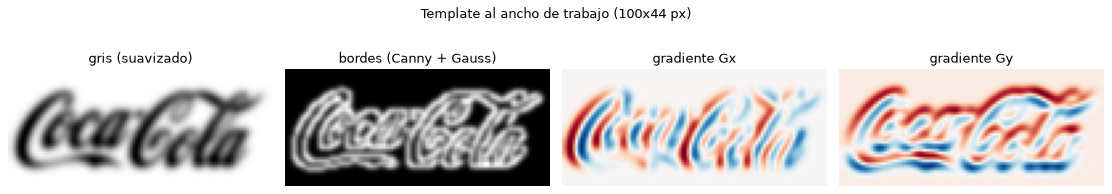

In [5]:
tw = 100
th = int(round(template_bgr.shape[0] * tw / template_bgr.shape[1]))
feats_tpl = extraer_caracteristicas(cv.resize(template_bgr, (tw, th), interpolation=cv.INTER_AREA))

fig, axes = plt.subplots(1, 4, figsize=(14, 2.8))
axes[0].imshow(feats_tpl["gris"], cmap="gray"); axes[0].set_title("gris (suavizado)")
axes[1].imshow(feats_tpl["bordes"], cmap="gray"); axes[1].set_title("bordes (Canny + Gauss)")
axes[2].imshow(feats_tpl["gradiente"][..., 0], cmap="RdBu"); axes[2].set_title("gradiente Gx")
axes[3].imshow(feats_tpl["gradiente"][..., 1], cmap="RdBu"); axes[3].set_title("gradiente Gy")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Template al ancho de trabajo ({tw}x{th} px)")
fig.tight_layout()
plt.show()

### 1.3 Detección única en cada imagen

Corremos el detector sobre las 7 imágenes y nos quedamos con la detección de mayor score. Para medir si es correcta anotamos a mano una caja aproximada alrededor del logo principal de cada imagen y calculamos el IoU con la detección; consideramos correcta una detección con IoU > 0.5. En `coca_multi.png` hay muchos logos, así que solo verificamos visualmente que el mejor candidato caiga sobre alguno.

Búsqueda multi-escala sobre las 7 imágenes: 30.0 s

imagen                  score  ancho  aspecto    IoU   2º candidato
----------------------------------------------------------------------
COCA-COLA-LOGO.jpg      0.601   1179     1.00   0.76          0.340
coca_logo_1.png         0.604    163     1.00   0.66          0.351
coca_logo_2.png         0.542    224     1.25   0.67          0.386
coca_multi.png          0.611     87     1.25    -            0.605
coca_retro_1.png        0.673    538     1.00   0.64          0.419
coca_retro_2.png        0.777    154     1.00   0.75          0.417
logo_1.png              0.581    292     1.00   0.72          0.329


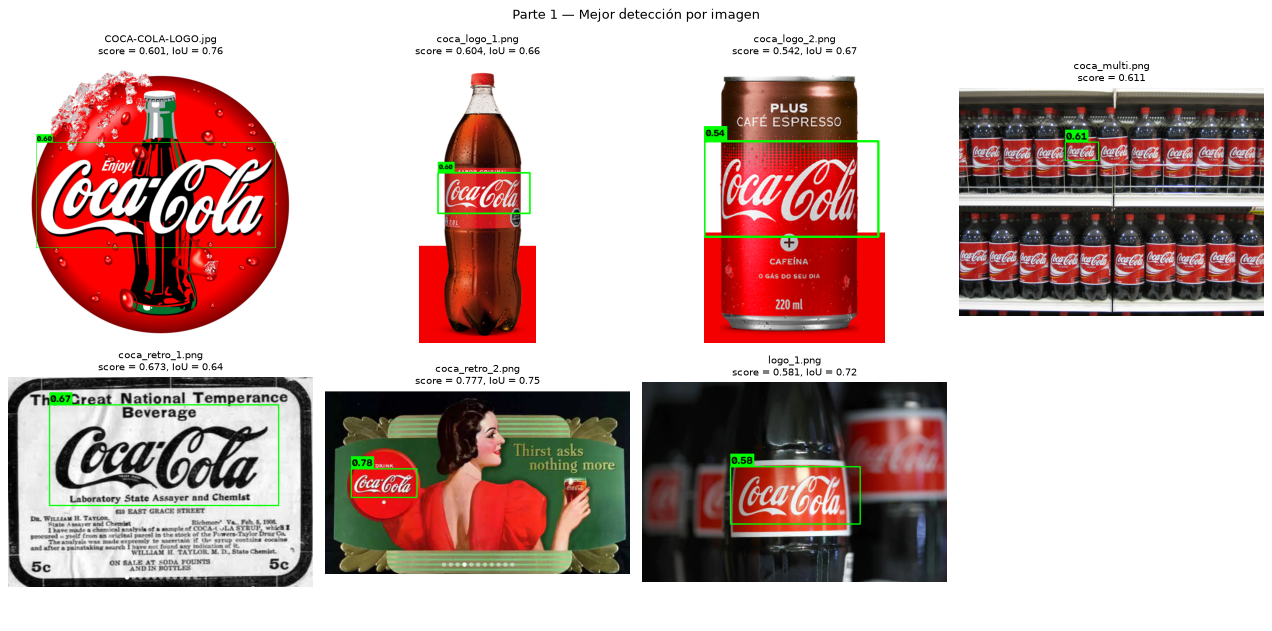

In [6]:
# Cajas aproximadas del logo principal, anotadas a mano (x0, y0, x1, y1)
ANOTACIONES = {
    "COCA-COLA-LOGO.jpg": (120, 470, 1260, 880),
    "coca_logo_1.png":    (35, 195, 175, 255),
    "coca_logo_2.png":    (15, 115, 220, 205),
    "coca_retro_1.png":   (120, 100, 600, 270),
    "coca_retro_2.png":   (60, 190, 210, 260),
    "logo_1.png":         (220, 210, 470, 320),
}

t0 = time.time()
candidatos = {nombre: buscar_logo(img, template_bgr) for nombre, img in imagenes.items()}
print(f"Búsqueda multi-escala sobre las {len(imagenes)} imágenes: {time.time() - t0:.1f} s")

print(f"\n{'imagen':22s} {'score':>6s} {'ancho':>6s} {'aspecto':>8s} {'IoU':>6s}  {'2º candidato':>13s}")
print("-" * 70)
resultados_p1 = {}
for nombre, dets in candidatos.items():
    mejor = dets[0]
    anot = ANOTACIONES.get(nombre)
    iou_txt = f"{iou(mejor['bbox'], anot):.2f}" if anot else "  -  "
    segundo = f"{dets[1]['score']:.3f}" if len(dets) > 1 else "-"
    print(f"{nombre:22s} {mejor['score']:6.3f} {mejor['ancho']:6.0f} {mejor['aspecto']:8.2f} {iou_txt:>6s}  {segundo:>13s}")
    resultados_p1[nombre] = (dibujar_detecciones(imagenes[nombre], [mejor]),
                             f"score = {mejor['score']:.3f}" + (f", IoU = {iou_txt}" if anot else ""))

mostrar_grilla(resultados_p1, "Parte 1 — Mejor detección por imagen", figsize=(16, 8))

Mapa de respuesta en la escala ganadora para una de las imágenes.

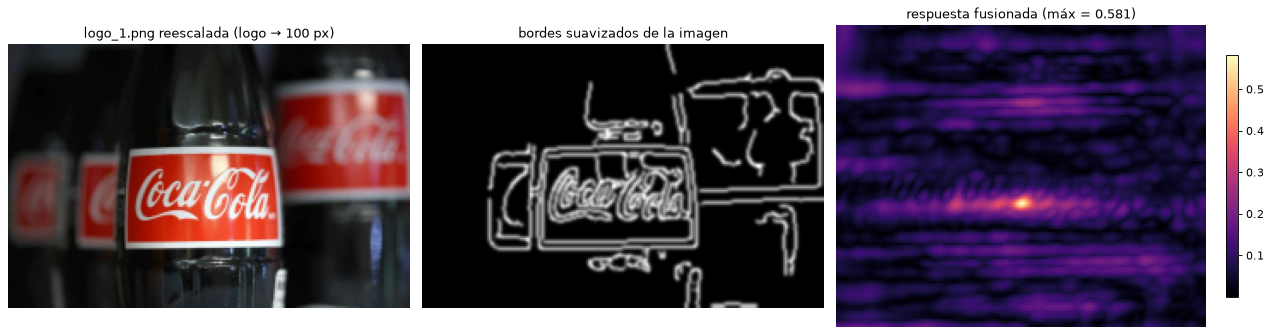

In [7]:
def mapa_respuesta(img_bgr, template_bgr, ancho_logo, aspecto, pesos=None, ancho_trabajo=100):
    '''Recalcula la respuesta fusionada para una escala/aspecto dados (para visualización).'''
    if pesos is None:
        pesos = {"bordes": 0.5, "gradiente": 0.5}
    tw = ancho_trabajo
    th = int(round(template_bgr.shape[0] * tw / template_bgr.shape[1]))
    feats_tpl = extraer_caracteristicas(cv.resize(template_bgr, (tw, th), interpolation=cv.INTER_AREA))
    H, W = img_bgr.shape[:2]
    f = tw / ancho_logo
    iw, ih = int(round(W * f)), int(round(H * f / aspecto))
    img_r = cv.resize(img_bgr, (iw, ih), interpolation=cv.INTER_AREA if f < 1 else cv.INTER_LINEAR)
    feats_img = extraer_caracteristicas(img_r)
    respuesta = sum(w * np.abs(cv.matchTemplate(feats_img[k], feats_tpl[k], cv.TM_CCOEFF_NORMED))
                    for k, w in pesos.items())
    return img_r, feats_img, respuesta


nombre_ej = "logo_1.png"
mejor = candidatos[nombre_ej][0]
img_r, feats_img, respuesta = mapa_respuesta(imagenes[nombre_ej], template_bgr, mejor["ancho"], mejor["aspecto"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].imshow(bgr2rgb(img_r)); axes[0].set_title(f"{nombre_ej} reescalada (logo → {tw} px)")
axes[1].imshow(feats_img["bordes"], cmap="gray"); axes[1].set_title("bordes suavizados de la imagen")
im = axes[2].imshow(respuesta, cmap="magma"); axes[2].set_title(f"respuesta fusionada (máx = {respuesta.max():.3f})")
plt.colorbar(im, ax=axes[2], fraction=0.03)
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

### 1.4 ¿Hacía falta el espacio de características?

Repetimos la búsqueda cambiando únicamente sobre qué se correlaciona: gris, solo bordes, solo gradientes o la fusión. Contamos en cuántas de las 6 imágenes anotadas la mejor detección es correcta y reportamos el margen global: la diferencia entre el score más bajo de un verdadero positivo y el más alto de un falso positivo (IoU < 0.1 con la anotación) a lo largo de todas las imágenes. Un margen positivo significa que existe un único umbral válido para todas las imágenes, que es lo que necesitamos en las partes 2 y 3.

In [8]:
CONFIGURACIONES = {
    "gris":                 {"gris": 1.0},
    "bordes":               {"bordes": 1.0},
    "gradiente":            {"gradiente": 1.0},
    "bordes + gradiente":   {"bordes": 0.5, "gradiente": 0.5},
}

imagenes_anotadas = {n: imagenes[n] for n in ANOTACIONES}

print(f"{'características':22s} {'correctas':>9s} {'min TP':>7s} {'max FP':>7s} {'margen':>7s}   tiempo")
print("-" * 70)
comparacion = {}
for etiqueta, pesos in CONFIGURACIONES.items():
    t0 = time.time()
    correctas, min_tp, max_fp = 0, 1.0, 0.0
    for nombre, img in imagenes_anotadas.items():
        dets = buscar_logo(img, template_bgr, pesos=pesos)
        anot = ANOTACIONES[nombre]
        tp = [d for d in dets if iou(d["bbox"], anot) > 0.5]
        fp = [d for d in dets if iou(d["bbox"], anot) < 0.1]
        correctas += int(iou(dets[0]["bbox"], anot) > 0.5)
        min_tp = min(min_tp, tp[0]["score"] if tp else 0.0)
        max_fp = max(max_fp, fp[0]["score"] if fp else 0.0)
    comparacion[etiqueta] = (correctas, min_tp, max_fp)
    print(f"{etiqueta:22s} {correctas:>5d}/{len(imagenes_anotadas)}   {min_tp:7.3f} {max_fp:7.3f} {min_tp - max_fp:+7.3f}   {time.time() - t0:5.1f} s")

características        correctas  min TP  max FP  margen   tiempo
----------------------------------------------------------------------


gris                       4/6     0.201   0.694  -0.493    25.0 s


bordes                     5/6     0.583   0.620  -0.037    32.8 s


gradiente                  6/6     0.364   0.391  -0.027    42.8 s


bordes + gradiente         6/6     0.542   0.419  +0.123    27.1 s


<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">

La pirámide de imagen y la correlación en valor absoluto resuelven la escala y la polaridad, pero no alcanzan solas: correlacionando gris el detector se equivoca en dos imágenes y el margen global es muy negativo, porque los scores de zonas rojas lisas con brillos, texto y botellas desenfocadas se mezclan con los del logo.

Bordes y gradientes son complementarios. Los bordes toleran diferencias de tipografía y pequeñas deformaciones y dan los scores más altos en el logo, pero no ven la orientación de los trazos, así que un renglón de texto denso también les responde. Los gradientes orientados son más selectivos, con falsos positivos mucho más bajos, pero castigan más las deformaciones (la lata de `coca_logo_2.png`). El promedio de ambos es la única configuración con 6/6 aciertos y margen positivo.

Con la fusión, la mejor detección de cada imagen tiene score mayor o igual a 0.54 y cae sobre el logo en todos los casos. Esto cumple el punto 1.

</div>

## Parte 2 — Múltiples detecciones en `coca_multi.png`

`buscar_logo` ya devuelve todos los máximos locales de todas las escalas que sobreviven al NMS. Para pasar a múltiples detecciones solo falta un umbral sobre el score, que al ser una correlación normalizada funciona como nivel de confianza entre 0 y 1. Para elegirlo miramos la distribución de scores de los candidatos, ordenados de mayor a menor.

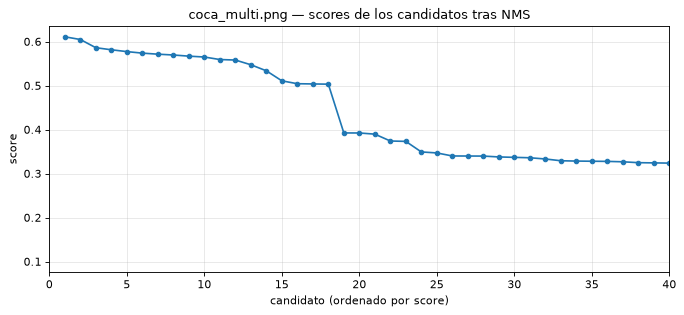

Primeros 25 scores: [0.611 0.605 0.586 0.581 0.577 0.574 0.571 0.569 0.567 0.565 0.559 0.558
 0.547 0.534 0.511 0.504 0.504 0.503 0.392 0.392 0.39  0.374 0.373 0.349
 0.347]


In [9]:
dets_multi = candidatos["coca_multi.png"]
scores_multi = np.array([d["score"] for d in dets_multi])

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(scores_multi) + 1), scores_multi, "o-", ms=4)
plt.xlabel("candidato (ordenado por score)")
plt.ylabel("score")
plt.title("coca_multi.png — scores de los candidatos tras NMS")
plt.xlim(0, 40)
plt.grid(alpha=0.3)
plt.show()

print("Primeros 25 scores:", np.round(scores_multi[:25], 3))

Hay un salto claro entre el candidato 18 y el 19: los primeros 18 tienen score entre 0.50 y 0.61 y a partir del 19 caen por debajo de 0.40. Elegimos como umbral el punto medio del margen medido en las 6 imágenes anotadas de la Parte 1 (min TP ≈ 0.54, max FP ≈ 0.42), que cae dentro de ese salto. Así el umbral no está ajustado a esta imagen en particular.

min TP = 0.542, max FP = 0.419  →  UMBRAL = 0.48
Detecciones en coca_multi.png con umbral 0.48: 18


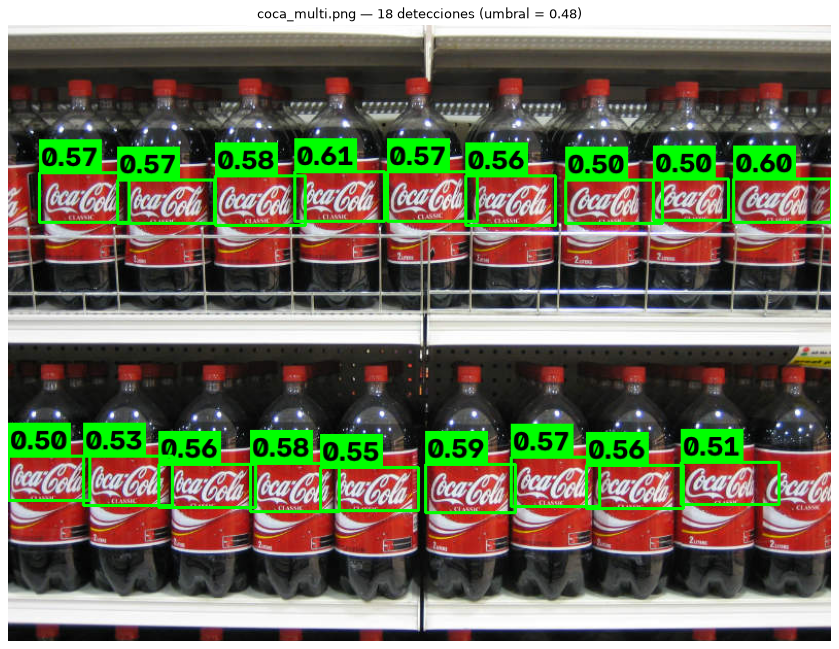

In [10]:
_, min_tp_fusion, max_fp_fusion = comparacion["bordes + gradiente"]
UMBRAL = round((min_tp_fusion + max_fp_fusion) / 2, 2)
print(f"min TP = {min_tp_fusion:.3f}, max FP = {max_fp_fusion:.3f}  →  UMBRAL = {UMBRAL}")


def detectar_logos(img_bgr, template_bgr, umbral=UMBRAL, **kwargs):
    '''Detector completo: búsqueda multi-escala + NMS + umbral de confianza.'''
    return [d for d in buscar_logo(img_bgr, template_bgr, **kwargs) if d["score"] >= umbral]


detecciones_multi = [d for d in dets_multi if d["score"] >= UMBRAL]
print(f"Detecciones en coca_multi.png con umbral {UMBRAL}: {len(detecciones_multi)}")

plt.figure(figsize=(14, 10))
plt.imshow(bgr2rgb(dibujar_detecciones(imagenes["coca_multi.png"], detecciones_multi)))
plt.title(f"coca_multi.png — {len(detecciones_multi)} detecciones (umbral = {UMBRAL})")
plt.axis("off")
plt.show()

Mostramos en azul los candidatos que quedaron justo por debajo del umbral, para ver qué es lo que estamos descartando.

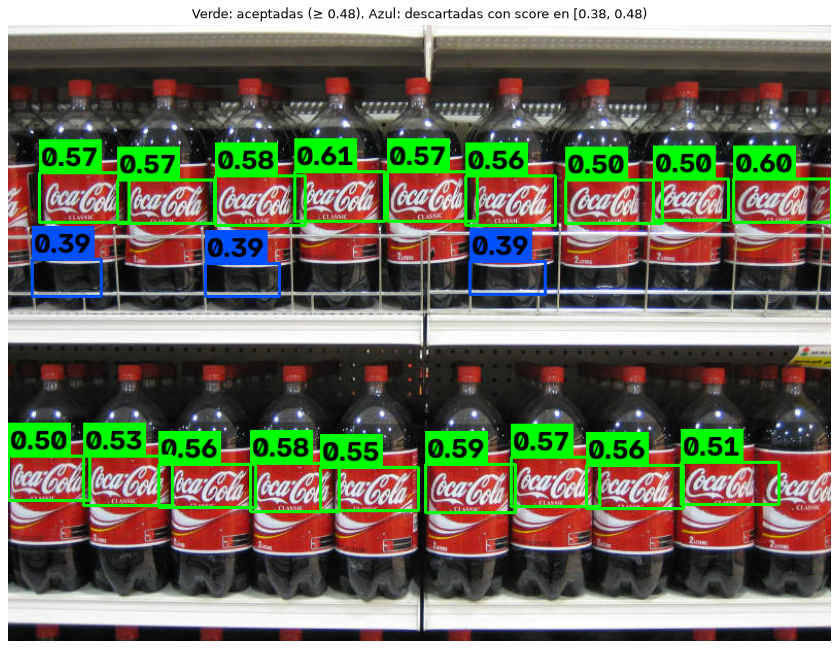

Scores de los descartados más cercanos al umbral: [0.392, 0.392, 0.39]


In [11]:
descartados_cerca = [d for d in dets_multi if UMBRAL - 0.1 <= d["score"] < UMBRAL]
vis = dibujar_detecciones(imagenes["coca_multi.png"], detecciones_multi, color=(0, 255, 0))
vis = dibujar_detecciones(vis, descartados_cerca, color=(255, 80, 0))

plt.figure(figsize=(14, 10))
plt.imshow(bgr2rgb(vis))
plt.title(f"Verde: aceptadas (≥ {UMBRAL}). Azul: descartadas con score en [{UMBRAL - 0.1:.2f}, {UMBRAL})")
plt.axis("off")
plt.show()

print("Scores de los descartados más cercanos al umbral:", [round(d["score"], 3) for d in descartados_cerca])

<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">

En `coca_multi.png` hay 18 etiquetas completas visibles, 9 por estante, y el detector devuelve exactamente 18 detecciones, una por etiqueta, sin falsos positivos ni duplicados. Los scores quedan agrupados entre 0.50 y 0.61 y la distribución muestra un salto neto por debajo del umbral.

Los candidatos justo debajo del umbral son las bases de las botellas del estante superior, sobre la rejilla metálica: regiones con muchos bordes horizontales y reflejos que al reescalarlas se parecen vagamente a una banda de texto. Quedan en 0.39, lejos del 0.50 de la etiqueta más débil.

El umbral sale del margen medido sobre las otras seis imágenes y aun así cae dentro del salto de scores de esta, lo que indica que el score es comparable entre imágenes. Esa es la condición para la Parte 3.

</div>

## Parte 3 — Generalización a todas las imágenes

Aplicamos `detectar_logos` con el mismo umbral a las 7 imágenes, sin cambiar ningún parámetro por imagen.

imagen                 detecciones   scores
----------------------------------------------------------------------
COCA-COLA-LOGO.jpg               1   [0.6]
coca_logo_1.png                  1   [0.6]
coca_logo_2.png                  1   [0.54]
coca_multi.png                  18   [0.61, 0.6, 0.59, 0.58, 0.58, 0.57, 0.57, 0.57, 0.57, 0.56, 0.56, 0.56, 0.55, 0.53, 0.51, 0.5, 0.5, 0.5]
coca_retro_1.png                 1   [0.67]
coca_retro_2.png                 1   [0.78]


logo_1.png                       1   [0.58]


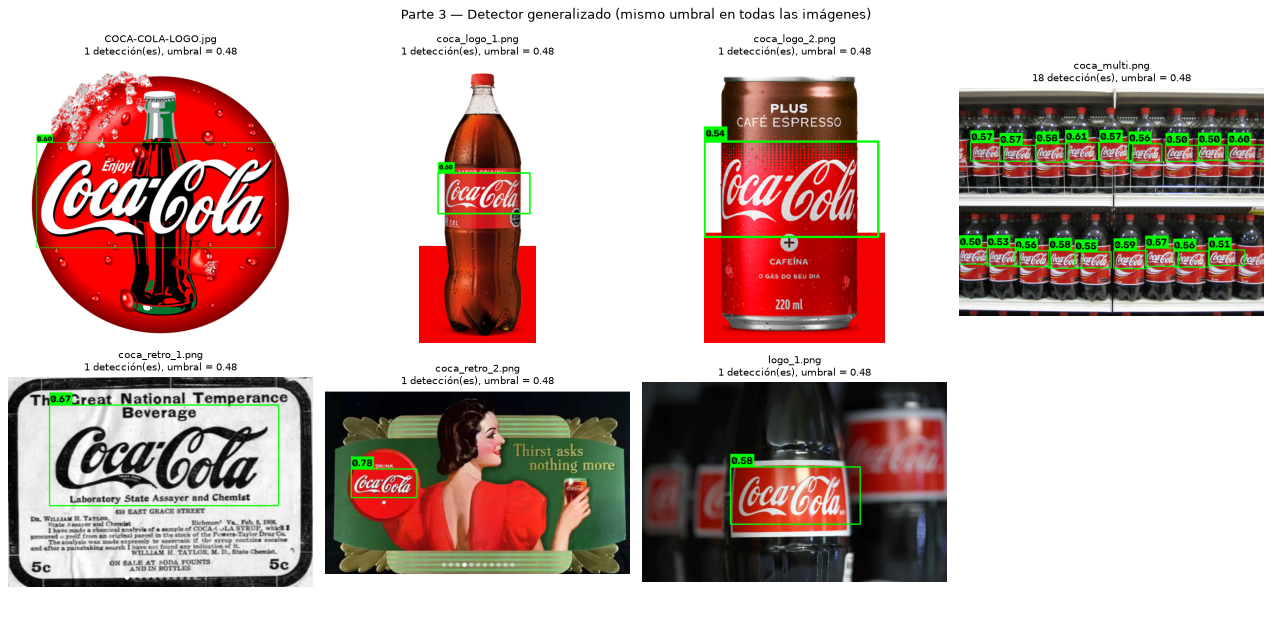

In [12]:
resultados_p3 = {}
print(f"{'imagen':22s} {'detecciones':>11s}   scores")
print("-" * 70)
for nombre, dets in candidatos.items():
    aceptadas = [d for d in dets if d["score"] >= UMBRAL]
    print(f"{nombre:22s} {len(aceptadas):>11d}   {[round(d['score'], 2) for d in aceptadas]}")
    resultados_p3[nombre] = (dibujar_detecciones(imagenes[nombre], aceptadas),
                             f"{len(aceptadas)} detección(es), umbral = {UMBRAL}")

mostrar_grilla(resultados_p3, "Parte 3 — Detector generalizado (mismo umbral en todas las imágenes)", figsize=(16, 8))

Para cada imagen mostramos también el mejor candidato rechazado, es decir, el de mayor score por debajo del umbral. Esto dice cuán lejos está el falso positivo más peligroso y si hay logos verdaderos que nos estemos perdiendo.

imagen                 mejor aceptada  mejor rechazada
------------------------------------------------------------
COCA-COLA-LOGO.jpg              0.601            0.340
coca_logo_1.png                 0.604            0.351
coca_logo_2.png                 0.542            0.386
coca_multi.png                  0.503            0.392
coca_retro_1.png                0.673            0.419
coca_retro_2.png                0.777            0.417
logo_1.png                      0.581            0.329


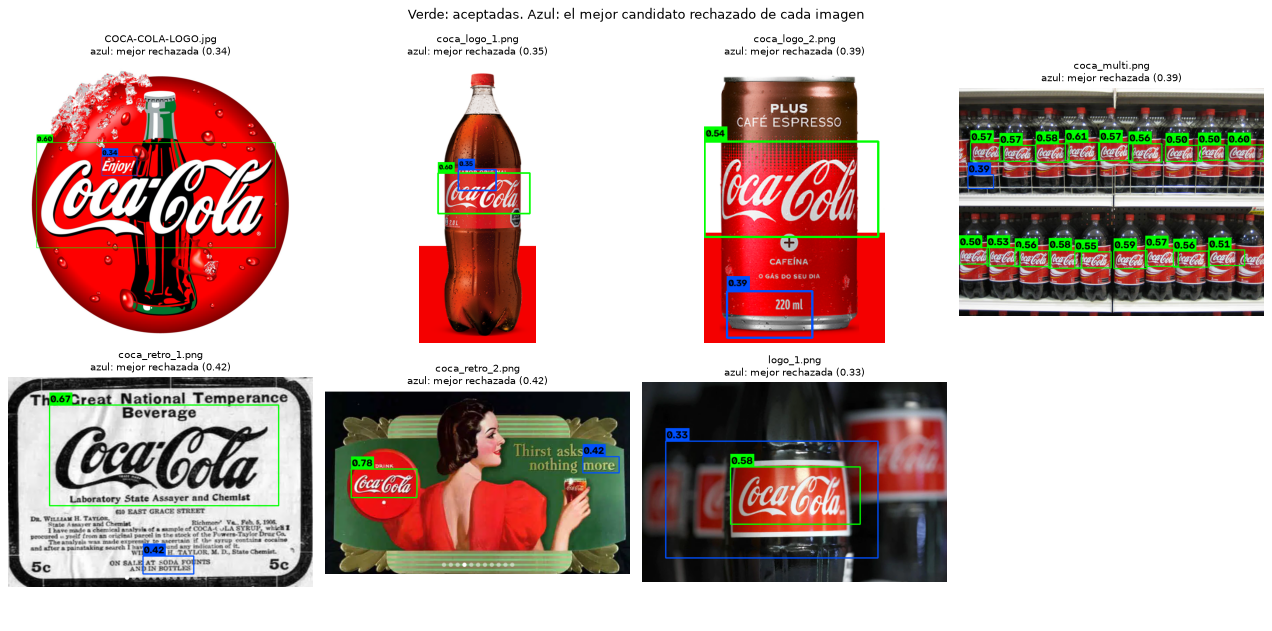

In [13]:
resultados_rechazados = {}
print(f"{'imagen':22s} {'mejor aceptada':>14s} {'mejor rechazada':>16s}")
print("-" * 60)
for nombre, dets in candidatos.items():
    aceptadas = [d for d in dets if d["score"] >= UMBRAL]
    rechazadas = [d for d in dets if d["score"] < UMBRAL]
    peor_ok = min(d["score"] for d in aceptadas)
    mejor_no = rechazadas[0]["score"] if rechazadas else float("nan")
    print(f"{nombre:22s} {peor_ok:14.3f} {mejor_no:16.3f}")
    vis = dibujar_detecciones(imagenes[nombre], aceptadas, color=(0, 255, 0))
    vis = dibujar_detecciones(vis, rechazadas[:1], color=(255, 80, 0))
    resultados_rechazados[nombre] = (vis, f"azul: mejor rechazada ({mejor_no:.2f})")

mostrar_grilla(resultados_rechazados, "Verde: aceptadas. Azul: el mejor candidato rechazado de cada imagen", figsize=(16, 8))

<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">

El detector generalizado encuentra el logo en las 7 imágenes con un solo umbral: una detección en cada imagen simple y las 18 etiquetas de `coca_multi.png`, sin falsos positivos.

El margen es cómodo en casi todas las imágenes. Los casos más ajustados son la lata curva de `coca_logo_2.png` (score 0.54, la deformación geométrica no la modela la pirámide) y los renglones de texto impreso, que son los falsos positivos más altos (0.42): el pie del aviso en `coca_retro_1.png` y el "nothing more" de `coca_retro_2.png`.

Lo que no detecta también es razonable: los logos borrosos de las botellas de fondo en `logo_1.png`, el logo diminuto del vaso en `coca_retro_2.png` y las etiquetas cortadas por el borde en `coca_multi.png`. Ahí la información de bordes se perdió por desenfoque, no hay resolución suficiente o el logo está incompleto.

</div>